#ONLINE SALES ANALYSIS: EXPLORING SALES PERFORMANCE, CUSTOMER'S BEHAIVOUR AND BUSINESS PATTERNS

#1. DATA IMPORT AND EXPLORATION

Import the dataset into your Google Colab Notebook

In [ ]:
#Import the python libaries
import pandas as pd
import numpy as np

In [ ]:
#Import the dataset to load the CSV file
df = pd.read_csv('/content/Online Sales Data-Capstone.csv')

Display the first few rows, dataset information, and summary statistics.

In [ ]:
#To preview the first few rows in the dataset
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,ShippingCost,Category,SalesChannel,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority
0,221958,SKU_1964,White Mug,38,1/1/2020 0:00,1.71,37039.0,Australia,0.47,Bank Transfer,10.79,Apparel,In-store,Not Returned,UPS,London,Medium
1,771155,SKU_1241,White Mug,18,1/1/2020 1:00,41.25,19144.0,Spain,0.19,paypall,9.51,Electronics,Online,Not Returned,UPS,Rome,Medium
2,231932,SKU_1501,Headphones,49,1/1/2020 2:00,29.11,50472.0,Germany,0.35,Bank Transfer,23.03,Electronics,Online,Returned,UPS,Berlin,High


In [ ]:
#To get the total number of rows and columns in the dataframe. The dataset contains 49,782 observations and 17 variables (columns)
df.shape

(49782, 17)

In [ ]:
#This returns all of the column headers in the dataframe. This healps to understand what information is available before deciding what analyses to perform.
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Discount', 'PaymentMethod',
       'ShippingCost', 'Category', 'SalesChannel', 'ReturnStatus',
       'ShipmentProvider', 'WarehouseLocation', 'OrderPriority'],
      dtype='object')

In [ ]:
#To change the column header to lowercase
df.columns = df.columns.str.lower()
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'discount', 'paymentmethod',
       'shippingcost', 'category', 'saleschannel', 'returnstatus',
       'shipmentprovider', 'warehouselocation', 'orderpriority'],
      dtype='object')

In [ ]:
#To display the general information and summary of the dataset including the data types.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49782 entries, 0 to 49781
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   invoiceno          49782 non-null  int64  
 1   stockcode          49782 non-null  object 
 2   description        49782 non-null  object 
 3   quantity           49782 non-null  int64  
 4   invoicedate        49782 non-null  object 
 5   unitprice          49782 non-null  float64
 6   customerid         44804 non-null  float64
 7   country            49782 non-null  object 
 8   discount           49782 non-null  float64
 9   paymentmethod      49782 non-null  object 
 10  shippingcost       47293 non-null  float64
 11  category           49782 non-null  object 
 12  saleschannel       49782 non-null  object 
 13  returnstatus       49782 non-null  object 
 14  shipmentprovider   49782 non-null  object 
 15  warehouselocation  46297 non-null  object 
 16  orderpriority      497

In [ ]:
#To display the statistical summary of numerical columns. I noticed that there a negative quantities.
df.describe()

,invoiceno,quantity,unitprice,customerid,discount,shippingcost
count,49782.000000,49782.000000,49782.000000,44804.000000,49782.000000,47293.000000
mean,550681.239946,22.372343,47.537862,55032.871775,0.275748,17.494529
std,260703.009944,17.917774,33.479510,25913.660157,0.230077,7.220557
min,100005.000000,-50.000000,-99.980000,10001.000000,0.000000,5.000000
25%,324543.000000,11.000000,23.592500,32750.750000,0.130000,11.220000
50%,552244.000000,23.000000,48.920000,55165.000000,0.260000,17.500000
75%,776364.000000,37.000000,74.610000,77306.250000,0.380000,23.720000
max,999997.000000,49.000000,100.000000,99998.000000,1.999764,30.000000


Identify potential issues such as missing data, duplicates, or incorrect data types.

In [ ]:
#This will show the number of missing values in each column. We expect to see missing values particularly in customerid, shippingcost and warehouselocation
df.isnull().sum()

,0
invoiceno,0
stockcode,0
description,0
quantity,0
invoicedate,0
unitprice,0
customerid,4978
country,0
discount,0
paymentmethod,0


In [ ]:
#To check for duplicated rows. this shows that the dataset has no complete duplicate rows.
df.duplicated().sum()

np.int64(0)

In [ ]:
#To display the datatype of every variable. The invoicedate column is in object format and needs to be changed to a datetime type for the time-based analysis
df.dtypes

,0
invoiceno,int64
stockcode,object
description,object
quantity,int64
invoicedate,object
unitprice,float64
customerid,float64
country,object
discount,float64
paymentmethod,object


#2. DATA CLEANING AND PREPROCESSING

Handle missing values appropriately (e.g., imputing, removing rows).

In [ ]:
df = pd.read_csv('/content/Online Sales Data-Capstone.csv')

In [ ]:
#To change the column header to lowercase
df.columns = df.columns.str.lower().str.strip()
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'discount', 'paymentmethod',
       'shippingcost', 'category', 'saleschannel', 'returnstatus',
       'shipmentprovider', 'warehouselocation', 'orderpriority'],
      dtype='object')

In [ ]:
#This will show the number of missing values in each column. We expect to see missing values particularly in customerid, shippingcost and warehouselocation
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,4978
Country,0
Discount,0
PaymentMethod,0


In [ ]:
#To get the median shipping cost
df['shippingcost'].median()

17.5

In [ ]:
#Missing shipping cost are replaced with the median shipping cost (17.5) since median is less affected by extreme values.
df.fillna({'shippingcost': df['shippingcost'].median()}, inplace=True)
df['shippingcost'].isnull().sum()



np.int64(0)

In [ ]:
#For warehouse we will use mode(the most occuring warejouse location) since it is a text data.
df['warehouselocation'].mode()[0]

'Amsterdam'

In [ ]:
#To replace the missing warehouse locations with the mode
df.fillna({'warehouselocation': df['warehouselocation'].mode()[0]}, inplace=True)
df['warehouselocation'].isnull().sum()

np.int64(0)

Missing cuatomerid values were retained because customerid is an identifier rather than a numerical measurement. Imputing these values with the mean, median, or mode could incorrectly assign transactions to customers.

In [ ]:
#to check missing value after treatment
df.isnull().sum()

,0
invoiceno,0
stockcode,0
description,0
quantity,0
invoicedate,0
unitprice,0
customerid,4978
country,0
discount,0
paymentmethod,0


Remove duplicates and handle outliers (e.g., using the IQR method)

In [ ]:
#This is to check the number of duplicated rows. After running the code No duplicate records were identified in the dataset; therefore, no observations were removed for duplication.
df.duplicated().sum()

np.int64(0)

In [ ]:
# i need to convert invoivedate to datetime format because it was stored as an object data type
df['invoicedate'] = pd.to_datetime(df['invoicedate'])
df['invoicedate'].dtype

dtype('<M8[ns]')

In [ ]:
#Checking for invalid numerica values. checking for negative values
print('negative quantity:', (df['quantity'] < 0).sum())
print('negative unitprice:', (df['unitprice'] < 0).sum())
print('negative shippingcost:', (df['shippingcost'] < 0).sum())


negative quantity: 2489
negative unitprice: 1493
negative shippingcost: 0


In [ ]:
#i want to confirm transactions with negative quantities
df.loc[df['quantity'] < 0, ['quantity', 'unitprice', 'returnstatus']].head(10)

,quantity,unitprice,returnstatus
4,-30,-68.11,Not Returned
144,-2,34.06,Not Returned
147,-26,-72.33,Not Returned
167,-19,-3.61,Not Returned
176,-3,85.95,Not Returned
199,-2,-96.08,Not Returned
262,-16,-73.60,Not Returned
292,-26,-51.94,Not Returned
314,-11,-44.40,Not Returned
330,-18,16.98,Not Returned


In [ ]:
# To remove transactions with negative or zero quantity and unit price
df = df[(df['quantity'] > 0) & (df['unitprice'] > 0)].copy()
df.shape

(47293, 18)

In [ ]:
#I want to use this to verify
print("Negative quantity:", (df['quantity'] < 0).sum())
print("Negative unitprice:", (df['unitprice'] < 0).sum())

Negative quantity: 0
Negative unitprice: 0


In [ ]:
#check discount variable
df['discount'].describe()

,discount
count,47293.000000
mean,0.250463
std,0.144324
min,0.000000
25%,0.130000
50%,0.250000
75%,0.380000
max,0.500000


In [ ]:
# Count discount values greater than 1

(df['discount'] > 1).sum()

np.int64(0)

In [ ]:
# Check for outliers using the IQR method

columns = ['quantity', 'unitprice', 'discount', 'shippingcost']

for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(column)
    print("Lower Bound:", round(lower_bound, 2))
    print("Upper Bound:", round(upper_bound, 2))
    print("Number of Outliers:", len(outliers))
    print()

quantity
Lower Bound: -23.0
Upper Bound: 73.0
Number of Outliers: 0

unitprice
Lower Bound: -48.5
Upper Bound: 149.7
Number of Outliers: 0

discount
Lower Bound: -0.24
Upper Bound: 0.76
Number of Outliers: 0

shippingcost
Lower Bound: -7.53
Upper Bound: 42.47
Number of Outliers: 0



In [ ]:
# To calculate IQR for unit price. The IQR method was used to identify potential outliers. Values below Q1 − 1.5(IQR) or above Q3 + 1.5(IQR) were considered potential outliers.
Q1 = df['unitprice'].quantile(0.25)
Q3 = df['unitprice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 25.82
Q3: 75.37
IQR: 49.550000000000004
Lower bound: -48.505
Upper bound: 149.695


In [ ]:
# To count potential outliers

outliers = df[
    (df['unitprice'] < lower_bound) |
    (df['unitprice'] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 0


Transform and scale the data if necessary.

Scaling was not applied because the analysis focuses on descriptive statistics, visualization, correlation, and statistical group comparisons rather than models that require variables to be standardized.

# 3. DATA VISUALIZATION

In [ ]:
# Import libraries for data visualization

import matplotlib.pyplot as plt
import seaborn as sns

Use Matplotlib to create static visualizations:
Histograms, bar charts, and scatter plots.
Use Seaborn for statistical visualizations:
Box plots, heatmaps, and pair plots.


I need to create total sales variable. Total sales is equals to quantity multiplied by Unit price multiplied by 1-discount

In [ ]:
# Calculate total sales after discount.
df['totalsales'] = (df['quantity'] * df['unitprice'] * (1 - df['discount']))
df[['quantity', 'unitprice', 'discount', 'totalsales']].head()

,quantity,unitprice,discount,totalsales
0,38,1.71,0.47,34.4394
1,18,41.25,0.19,601.4250
2,49,29.11,0.35,927.1535
3,14,76.68,0.14,923.2272
5,47,70.16,0.48,1714.7104


In [ ]:
# Summary statistics for total sales

df['totalsales'].describe()

,totalsales
count,47293.000000
mean,943.769574
std,851.748526
min,0.717100
25%,260.000000
50%,691.247200
75%,1403.520000
max,4847.119200


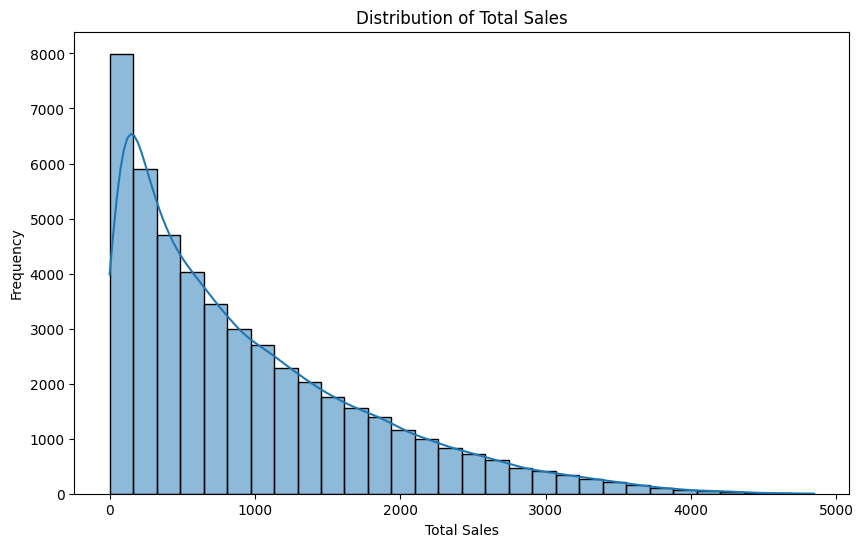

In [ ]:
# Histogram showing the distribution of total sales. A histogram was used to examine the distribution of total sales across transactions
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='totalsales', bins=30, kde=True)
plt.title('Distribution of Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# I calculate total sales for each product category to know which product categories generate the most sales?
category_sales = (df.groupby('category')['totalsales'] .sum().sort_values(ascending=False))
category_sales

,totalsales
category,
Furniture,9.029879e+06
Accessories,8.956126e+06
Apparel,8.893156e+06
Electronics,8.883924e+06
Stationery,8.870610e+06


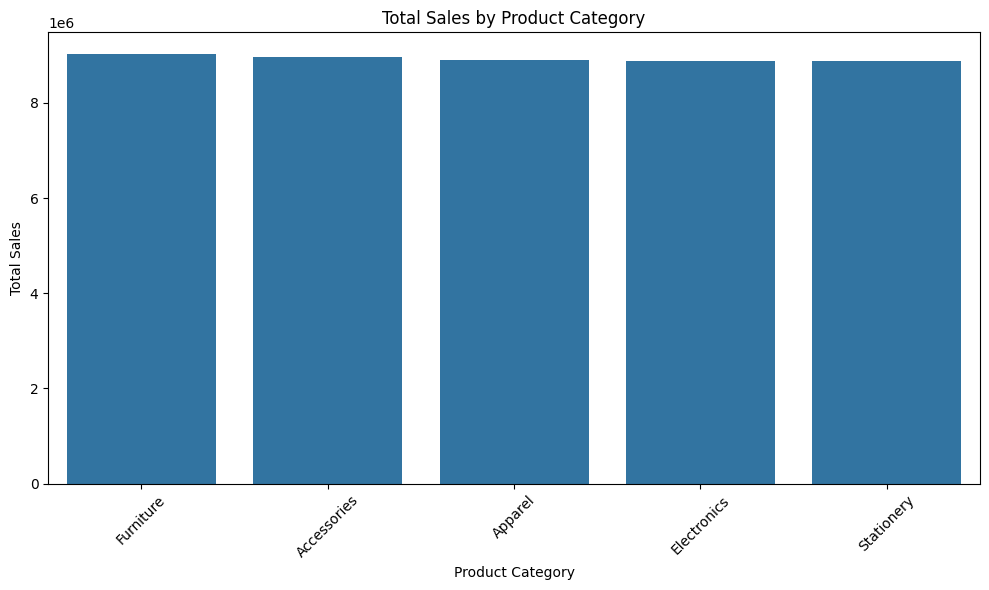

In [ ]:
# Bar chart showing total sales by product category

plt.figure(figsize=(10, 6))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# I calculate total sales for each sales channel to know whether sales differ between the available channels
channel_sales = (df.groupby('saleschannel')['totalsales'].sum().sort_values(ascending=False))
channel_sales

,totalsales
saleschannel,
Online,2.237086e+07
In-store,2.226283e+07


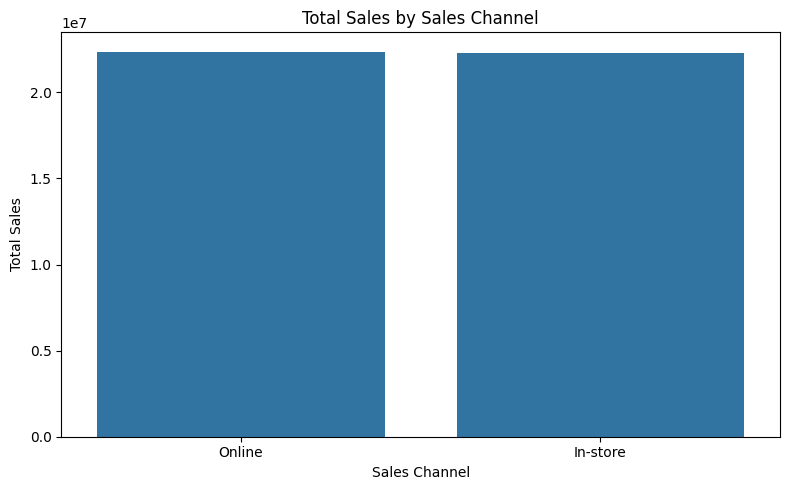

In [ ]:
# Bar chart showing total sales by sales channel
plt.figure(figsize=(8, 5))
sns.barplot(x=channel_sales.index, y=channel_sales.values)
plt.title('Total Sales by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [ ]:
# i want to extract year and month from invoicedate so as to examine how sales changed overtime
df['month'] = df['invoicedate'].dt.to_period('M')
df[['invoicedate', 'month']].head()

,invoicedate,month
0,2020-01-01 00:00:00,2020-01
1,2020-01-01 01:00:00,2020-01
2,2020-01-01 02:00:00,2020-01
3,2020-01-01 03:00:00,2020-01
5,2020-01-01 05:00:00,2020-01


In [ ]:
#To calculate total sales for each month
monthly_sales = df.groupby('month')['totalsales'].sum()
monthly_sales

,totalsales
month,
2020-01,639802.6723
2020-02,633880.3685
2020-03,665145.3136
2020-04,669340.3163
2020-05,656741.3049
...,...
2025-05,663107.4327
2025-06,615998.8374
2025-07,657156.3931


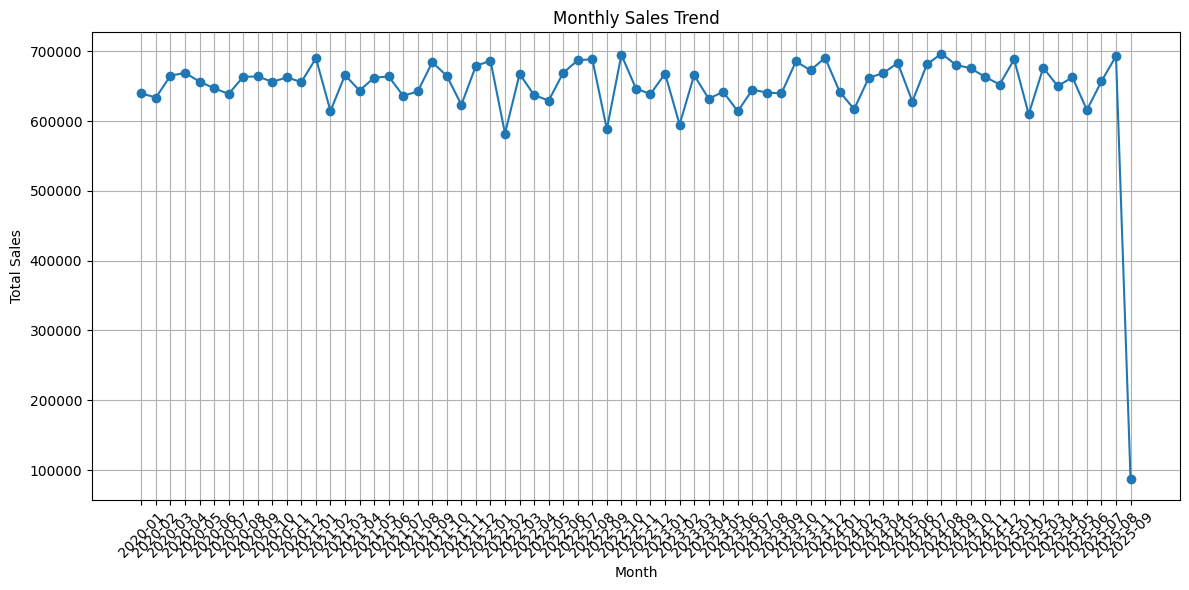

In [ ]:
#I plot monthly sales trend on a line graph
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#To check the number of transactions by payment method
df['paymentmethod'].value_counts()

,count
paymentmethod,
Bank Transfer,15933
Credit Card,15721
paypall,15639


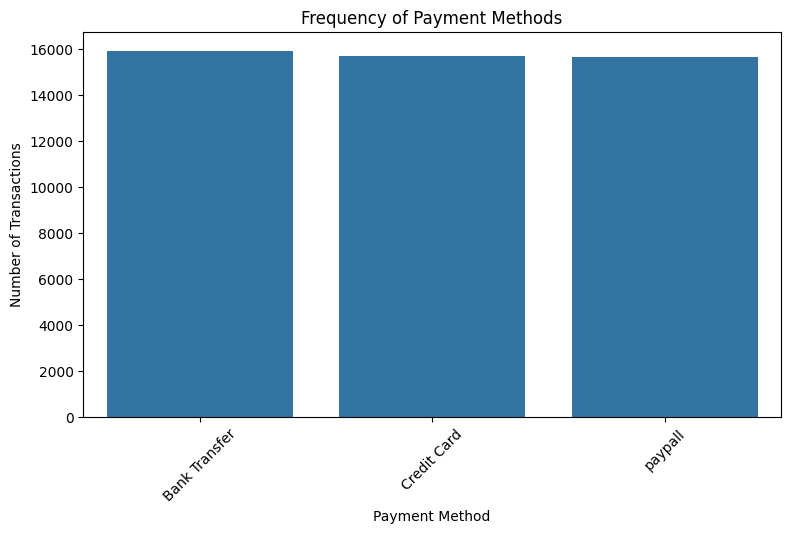

In [ ]:
#Then i plot the frequency of payment methods
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='paymentmethod', order=df['paymentmethod'].value_counts().index)
plt.title('Frequency of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Check the number of transactions by return status to examine returned and not-returned transactions
df['returnstatus'].value_counts()

,count
returnstatus,
Not Returned,42647
Returned,4646


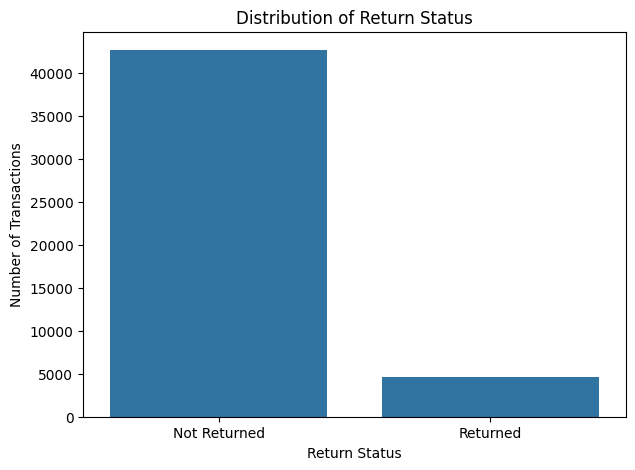

In [ ]:
# Plot the distribution of return status
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='returnstatus', order=df['returnstatus'].value_counts().index)
plt.title('Distribution of Return Status')
plt.xlabel('Return Status')
plt.ylabel('Number of Transactions')
plt.show()

In [ ]:
#his is to heck the frequency of each order priority
df['orderpriority'].value_counts()

,count
orderpriority,
Medium,15822
High,15763
Low,15708


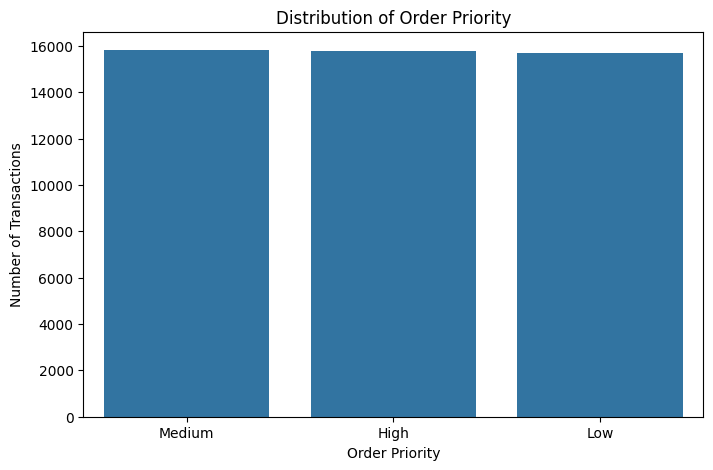

In [ ]:
#To plot the distribution of order priority
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='orderpriority', order=df['orderpriority'].value_counts().index)
plt.title('Distribution of Order Priority')
plt.xlabel('Order Priority')
plt.ylabel('Number of Transactions')
plt.show()

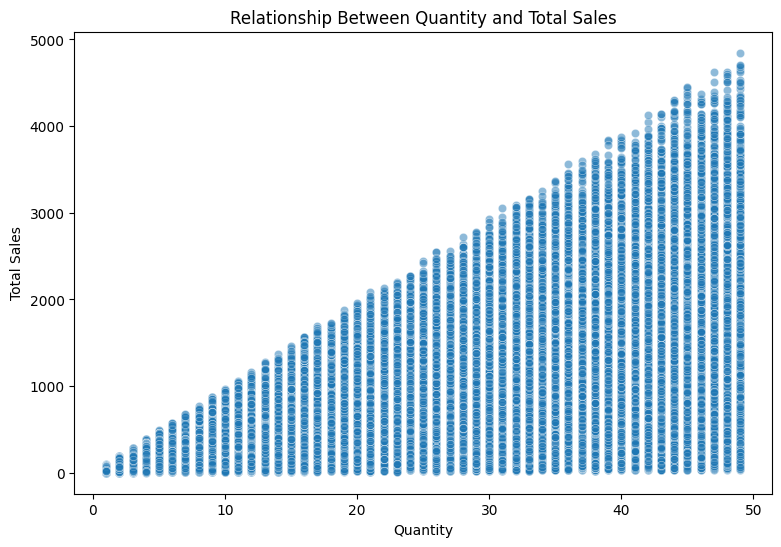

In [ ]:
# Scatter plot of quantity and total sales. This allows us to investigate whether larger quantities tend to be associated with higher transaction sales.
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='quantity', y='totalsales', alpha=0.5)
plt.title('Relationship Between Quantity and Total Sales')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
#This is to select numerical variables for correlation analysis
numerical_data = df[['quantity', 'unitprice', 'discount', 'shippingcost', 'totalsales']]

In [ ]:
#To calculate correlation matrix. Values close to +1 indicate a strong positive relationship, values near 0 indicate little linear relationship, and values close to −1 indicate a strong negative relationship.
correlation_matrix = numerical_data.corr()
correlation_matrix

,quantity,unitprice,discount,shippingcost,totalsales
quantity,1.000000,-0.002722,0.000757,-0.004086,0.629699
unitprice,-0.002722,1.000000,-0.005394,0.003112,0.627558
discount,0.000757,-0.005394,1.000000,-0.001282,-0.218366
shippingcost,-0.004086,0.003112,-0.001282,1.000000,-0.000334
totalsales,0.629699,0.627558,-0.218366,-0.000334,1.000000


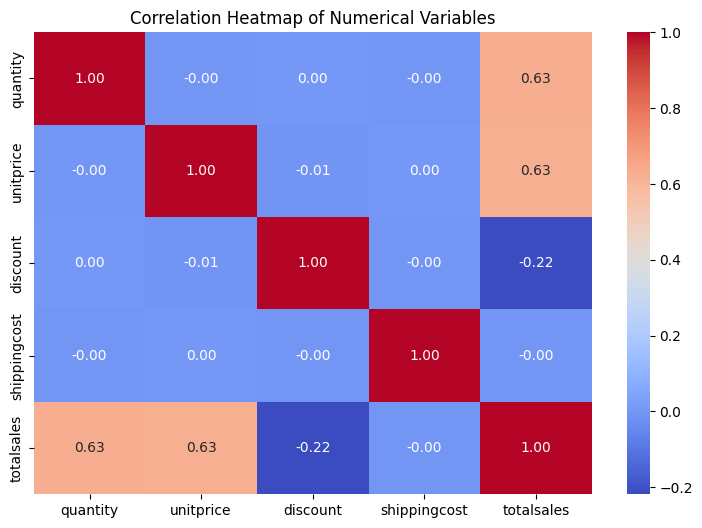

In [ ]:
#Create and plot correlation heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [ ]:
# Calculate total sales by product category and sales channel to investigate how do product-category sales compare across the different sales channesls
category_channel_sales = (df.groupby(['category', 'saleschannel'])['totalsales'].sum().reset_index())
category_channel_sales.head()

,category,saleschannel,totalsales
0,Accessories,In-store,4.464060e+06
1,Accessories,Online,4.492066e+06
2,Apparel,In-store,4.492738e+06
3,Apparel,Online,4.400418e+06
4,Electronics,In-store,4.364167e+06


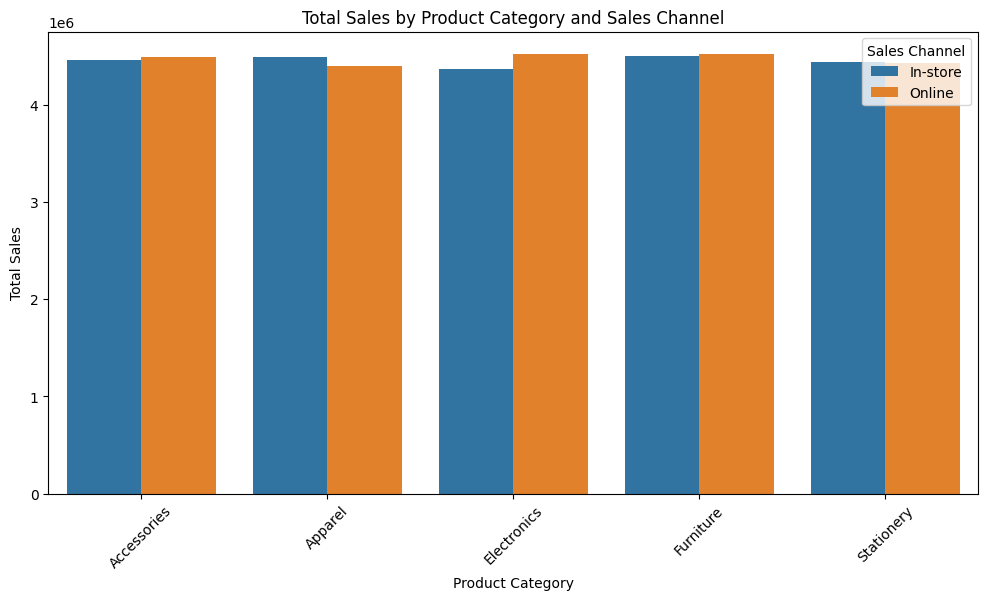

In [ ]:
#I create a grouped bar chart of category sales by sales channel
plt.figure(figsize=(12, 6))
sns.barplot(data=category_channel_sales,x='category', y='totalsales', hue='saleschannel')
plt.title('Total Sales by Product Category and Sales Channel')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend(title='Sales Channel')
plt.show()

#4. EXPLORATORY DATA ANALYSIS (EDA)

Identify patterns, trends, or relationships in the data.

OVERALL SALES PERFORMANCE: The overall sales analysis provides a summary of the size and value of the transactions in the cleaned dataset. Total sales, average and median transaction values, total quantity sold, and the number of transactions provide a baseline for the subsequent group comparisons.

In [ ]:
#I want to check the overall sales performance, so i calculate key sales performance measures
print("Total Sales:", round(df['totalsales'].sum(), 2))
print("Average Sales per Transaction:", round(df['totalsales'].mean(), 2))
print("Median Sales per Transaction:", round(df['totalsales'].median(), 2))
print("Total Quantity Sold:", df['quantity'].sum())
print("Number of Transactions:", len(df))

Total Sales: 44633694.47
Average Sales per Transaction: 943.77
Median Sales per Transaction: 691.25
Total Quantity Sold: 1177292
Number of Transactions: 47293


PRODUCT CATEGORY PERFORMANCE: Product categories differ in their sales performance.Furniture generated the highest total sales, while stationery recorded the lowest. The results also show differences in average transaction value, quantity sold, and number of transactions across categories.

In [ ]:
# Calculate sales performance by product category to know which product categories generate the highest sales performance
category_performance = df.groupby('category').agg(total_sales=('totalsales', 'sum'),
    average_sales=('totalsales', 'mean'),total_quantity=('quantity', 'sum'),
    number_of_transactions=('invoiceno', 'count'))
category_performance = category_performance.sort_values(by='total_sales',ascending=False)
category_performance

,total_sales,average_sales,total_quantity,number_of_transactions
category,,,,
Furniture,9.029879e+06,942.871310,238212,9577
Accessories,8.956126e+06,947.337212,235174,9454
Apparel,8.893156e+06,947.794528,233952,9383
Electronics,8.883924e+06,941.791963,232894,9433
Stationery,8.870610e+06,939.086416,237060,9446


SALES CHANNEL PERFORMANCE: Sales performance varies across sales channels. The comparison considers not only total sales but also average transaction value, total quantity sold, and transaction frequency, providing a broader assessment of channel performance.

In [ ]:
# Compare sales performance across sales channels to know how sales performance differ across sales channels
channel_performance = df.groupby('saleschannel').agg(total_sales=('totalsales', 'sum'),
    average_sales=('totalsales', 'mean'),total_quantity=('quantity', 'sum'),
    number_of_transactions=('invoiceno', 'count'))
channel_performance = channel_performance.sort_values(by='total_sales',ascending=False)
channel_performance

,total_sales,average_sales,total_quantity,number_of_transactions
saleschannel,,,,
Online,2.237086e+07,941.455441,591346,23762
In-store,2.226283e+07,946.106425,585946,23531


SALES PERFORMANCE BY COUNTRY: The country-level analysis shows that sales are not distributed equally across markets. The top ten countries account for the highest sales values in the dataset, with Belgium recording the highest total sales.

In [ ]:
#To see how many number of countries are represented in the dataset
df['country'].nunique()

12

In [ ]:
# Calculate total sales by country
country_sales = (df.groupby('country')['totalsales'].sum().sort_values(ascending=False))
country_sales

,totalsales
country,
Belgium,3.834826e+06
United Kingdom,3.796476e+06
United States,3.784707e+06
Sweden,3.772469e+06
Germany,3.752837e+06
France,3.747060e+06
Spain,3.705807e+06
Portugal,3.703388e+06
Norway,3.684369e+06


In [ ]:
#To display the top 10 countries by total sales
top10_countries = country_sales.head(10)
top10_countries

,totalsales
country,
Belgium,3.834826e+06
United Kingdom,3.796476e+06
United States,3.784707e+06
Sweden,3.772469e+06
Germany,3.752837e+06
France,3.747060e+06
Spain,3.705807e+06
Portugal,3.703388e+06
Norway,3.684369e+06


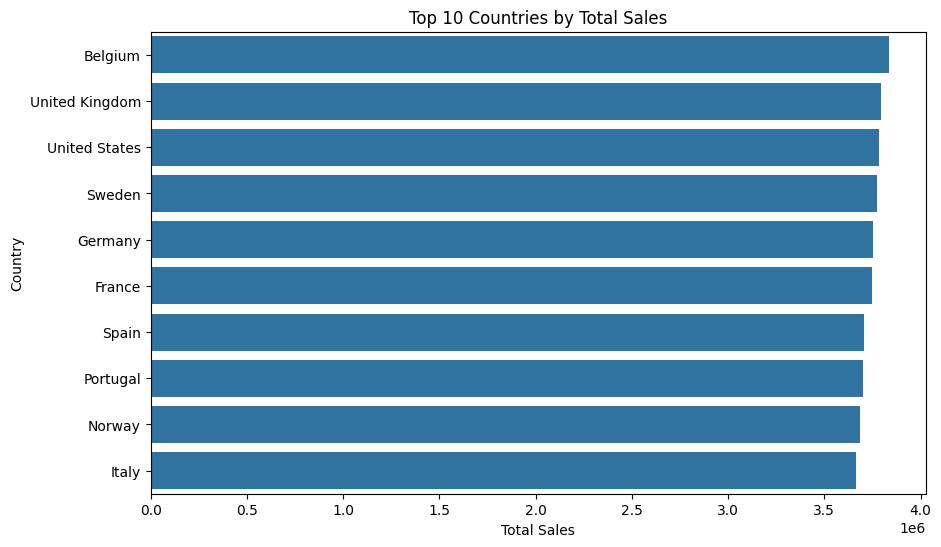

In [ ]:
#Plot the top 10 countries by total sales. I used horizontal bar because country's name can be long.
plt.figure(figsize=(10, 6))
sns.barplot(x=top10_countries.values, y=top10_countries.index)
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.show()

PAYMENT METHOD AND SALES PERFORMANCE: Payment methods were compared using total sales, average transaction value, and transaction frequency. This allows the analysis to distinguish between payment methods that are frequently used and those associated with higher-value transactions.

In [ ]:
#I analyze sales performance by payment method to know which payment methods are associated with the highest sales
payment_performance = df.groupby('paymentmethod').agg(total_sales=('totalsales', 'sum'),
    average_sales=('totalsales', 'mean'),number_of_transactions=('invoiceno', 'count'))
payment_performance = payment_performance.sort_values(by='total_sales',ascending=False)
payment_performance

,total_sales,average_sales,number_of_transactions
paymentmethod,,,
Bank Transfer,1.514442e+07,950.506436,15933
Credit Card,1.476759e+07,939.354408,15721
paypall,1.472168e+07,941.344381,15639


In [ ]:
#Calculate correlation between quantity and total sales
quantity_sales_corr = df['quantity'].corr(df['totalsales'])
print("Correlation between Quantity and Total Sales:",
      round(quantity_sales_corr, 3))

Correlation between Quantity and Total Sales: 0.63


RELATIONSHIP BETWEEN QUANTITY AND TOTAL SALES: The correlation coefficient between Quantity and Total Sales is 0.63. This indicates a moderate positive linear relationship between the two variables.

In [ ]:
#Calculate correlation between unit price and total sales
price_sales_corr = df['unitprice'].corr(df['totalsales'])
print("Correlation between Unit Price and Total Sales:",
round(price_sales_corr, 3))

Correlation between Unit Price and Total Sales: 0.628


RELATIONSHIP BETWEEN UNIT PRICE AND TOTAL SALES: The correlation coefficient between unit price and Total Sales is 0.628. This indicates a moderate positive linear relationship between the two variables.

In [ ]:
#Calculate correlation between discount and total sales
discount_sales_corr = df['discount'].corr(df['totalsales'])
print("Correlation between Discount and Total Sales:",
round(discount_sales_corr, 3))

Correlation between Discount and Total Sales: -0.218


RELATIONSHIP BETWEEN DISCOUNT AND TOTAL SALES: The correlation coefficient between Discount and Total Sales is -0.218. This indicates a weak negative linear relationship between the two variables.

In [ ]:
#Calculate correlation between shipping cost and total sales
shipping_sales_corr = df['shippingcost'].corr(df['totalsales'])
print("Correlation between Shipping Cost and Total Sales:",
round(shipping_sales_corr, 3))

Correlation between Shipping Cost and Total Sales: -0.0


RELATIONSHIP BETWEEN SHIPPING COST AND TOTAL SALES: The correlation coefficient between Discount and Total Sales is -0.0. This indicates a weak negative linear relationship between the two variables.

SUMMARY

In [ ]:
#To display all correlations with total sales
sales_correlations = df[['quantity', 'unitprice', 'discount','shippingcost', 'totalsales']].corr()['totalsales'].sort_values(ascending=False)
sales_correlations

,totalsales
totalsales,1.000000
quantity,0.629699
unitprice,0.627558
shippingcost,-0.000334
discount,-0.218366


#5. STATISTICAL ANALYSIS

In [ ]:
#Import statistical libraries
from scipy import stats

In [ ]:
#Set significance level
alpha = 0.05

In [ ]:
#Check the sales channels. To test if there is a statistically significant difference in average total sales between the two sales channels
df['saleschannel'].value_counts()

,count
saleschannel,
Online,23762
In-store,23531


In [ ]:
#To separate total sales for the two sales channels
online_sales = df.loc[df['saleschannel'] == 'Online','totalsales']
instore_sales = df.loc[df['saleschannel'] == 'In-store','totalsales']
print("Online observations:", len(online_sales))
print("In-store observations:", len(instore_sales))

Online observations: 23762
In-store observations: 23531


In [ ]:
#Compare mean total sales between the two channels
print("Average Online Sales:",
      round(online_sales.mean(), 2))
print("Average In-store Sales:",
      round(instore_sales.mean(), 2))

Average Online Sales: 941.46
Average In-store Sales: 946.11


Research Question: Is there a statistically significant difference in average total sales between Online and In-store sales channels?

H₀: There is no statistically significant difference in mean total sales between Online and In-store sales channels.

H₁: There is a statistically significant difference in mean total sales between Online and In-store sales channels.

A significance level of α = 0.05 is used.

In [ ]:
#Perform independent two-sample t-test
t_stat, p_value = stats.ttest_ind(online_sales,instore_sales,equal_var=False)
print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 4))

T-statistic: -0.594
P-value: 0.5527


In [ ]:
#Make decision based on the p-value
if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in mean total sales between the sales channels.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is insufficient evidence of a significant difference in mean total sales between the sales channels.")

Fail to reject the null hypothesis.
There is insufficient evidence of a significant difference in mean total sales between the sales channels.


In [ ]:
#Display product categories
df['category'].value_counts()

,count
category,
Furniture,9577
Accessories,9454
Stationery,9446
Electronics,9433
Apparel,9383


In [ ]:
#Create total sales groups for each product category
category_groups = [group['totalsales'].values
    for name, group in df.groupby('category')]

Research Question: Is there a statistically significant difference in average total sales across product categories?

H₀: There is no statistically significant difference in mean total sales across product categories.

H₁: At least one product category has a significantly different mean total sales value.

In [ ]:
#Perform one-way ANOVA
f_stat, p_value_anova = stats.f_oneway(*category_groups)
print("F-statistic:", round(f_stat, 3))
print("P-value:", round(p_value_anova, 4))

F-statistic: 0.181
P-value: 0.9485


In [ ]:
# Make decision for ANOVA

if p_value_anova < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in mean total sales among the product categories.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is insufficient evidence of a significant difference in mean total sales among the product categories.")

Fail to reject the null hypothesis.
There is insufficient evidence of a significant difference in mean total sales among the product categories.


In [ ]:
#Create contingency table for sales channel and return status
contingency_table = pd.crosstab(df['saleschannel'],df['returnstatus'])
contingency_table

returnstatus,Not Returned,Returned
saleschannel,,
In-store,21210,2321
Online,21437,2325


Research Question: Is there a statistically significant association between sales channel and return status?

H₀: Sales channel and return status are independent; there is no statistically significant association between them.

H₁: Sales channel and return status are associated.

In [ ]:
#Perform chi-square test of independence
chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency_table)
print("Chi-square statistic:", round(chi2, 3))
print("P-value:", round(p_value_chi, 4))
print("Degrees of freedom:", dof)

Chi-square statistic: 0.075
P-value: 0.7846
Degrees of freedom: 1


In [ ]:
# Make decision for chi-square test

if p_value_chi < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant association between sales channel and return status.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is insufficient evidence of a significant association between sales channel and return status.")

Fail to reject the null hypothesis.
There is insufficient evidence of a significant association between sales channel and return status.


In [ ]:
#Create summary of statistical tests
statistical_results = pd.DataFrame({'Test': ['Independent T-Test','One-Way ANOVA','Chi-Square Test'],
  'Variables': ['Total Sales by Sales Channel','Total Sales by Product Category','Sales Channel vs Return Status'],
  'P-Value': [p_value,p_value_anova,p_value_chi]})
statistical_results
#Add statistical decision
statistical_results['Decision'] = statistical_results['P-Value'].apply(lambda x: 'Reject H0' if x < alpha else 'Fail to Reject H0')
statistical_results

,Test,Variables,P-Value,Decision
0,Independent T-Test,Total Sales by Sales Channel,0.552681,Fail to Reject H0
1,One-Way ANOVA,Total Sales by Product Category,0.948536,Fail to Reject H0
2,Chi-Square Test,Sales Channel vs Return Status,0.784582,Fail to Reject H0


In [ ]:
#Make decision for chi-square test
if p_value_chi < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant association between sales channel and return status.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is insufficient evidence of a significant association between sales channel and return status.")

#Create summary of statistical tests
statistical_results = pd.DataFrame({
    'Test': ['Independent T-Test','One-Way ANOVA','Chi-Square Test'],'Variables': ['Total Sales by Sales Channel','Total Sales by Product Category','Sales Channel vs Return Status'],
    'P-Value': [p_value,p_value_anova,p_value_chi]})
statistical_results

#Add statistical decision
statistical_results['Decision'] = statistical_results['P-Value'].apply(lambda x: 'Reject H0' if x < alpha else 'Fail to Reject H0')
statistical_results

Fail to reject the null hypothesis.
There is insufficient evidence of a significant association between sales channel and return status.


,Test,Variables,P-Value,Decision
0,Independent T-Test,Total Sales by Sales Channel,0.552681,Fail to Reject H0
1,One-Way ANOVA,Total Sales by Product Category,0.948536,Fail to Reject H0
2,Chi-Square Test,Sales Channel vs Return Status,0.784582,Fail to Reject H0


SUMMARY: The statistical tests were used to determine whether the patterns observed in the data were statistically significant. The results from the t-test, ANOVA, and chi-square test provide evidence for evaluating differences in sales performance and associations between key categorical variables. Decisions were made at the 5% significance level based on the respective p-values.

#6. DATA TRANSFORMATION AND JOINING

Practice subsetting data with loc and iloc.
Merge datasets (if required) to enrich your analysis.
Use pivot tables to summarize data.


The loc method was used to select transactions where totalsales is greater than the overall average and displays only the four relevant columns

In [ ]:
#Calculate average total sales and select transactions with total sales greater than the average.
average_sales = df['totalsales'].mean()

#Select transactions with above-average sales using loc

above_average_sales = df.loc[df['totalsales'] > average_sales,['invoiceno', 'category', 'saleschannel', 'totalsales']]
above_average_sales.head()

,invoiceno,category,saleschannel,totalsales
5,744167,Electronics,Online,1714.7104
6,210268,Stationery,Online,1821.9750
8,154886,Apparel,Online,1772.3295
9,237337,Apparel,Online,3298.5120
10,621430,Stationery,In-store,3475.2564


In [ ]:
#Select the first 10 rows and first 5 columns using iloc. iloc selects data according to row and column positions. The iloc method was used to select the first 10 rows and first 5 columns based on their positions in the dataset
df.iloc[:10, :5]

,invoiceno,stockcode,description,quantity,invoicedate
0,221958,SKU_1964,White Mug,38,2020-01-01 00:00:00
1,771155,SKU_1241,White Mug,18,2020-01-01 01:00:00
2,231932,SKU_1501,Headphones,49,2020-01-01 02:00:00
3,465838,SKU_1760,Desk Lamp,14,2020-01-01 03:00:00
5,744167,SKU_1006,Office Chair,47,2020-01-01 05:00:00
6,210268,SKU_1087,USB Cable,25,2020-01-01 06:00:00
7,832180,SKU_1597,Notebook,8,2020-01-01 07:00:00
8,154886,SKU_1907,Wireless Mouse,19,2020-01-01 08:00:00
9,237337,SKU_1866,Headphones,40,2020-01-01 09:00:00
10,621430,SKU_1144,Notebook,49,2020-01-01 10:00:00


In [ ]:
# Create pivot table of total sales by category and sales channel. i use a pivot table to summarize sales by product category and sales channel.
sales_pivot = pd.pivot_table(df,values='totalsales',index='category',columns='saleschannel',aggfunc='sum')
sales_pivot

saleschannel,In-store,Online
category,,
Accessories,4.464060e+06,4.492066e+06
Apparel,4.492738e+06,4.400418e+06
Electronics,4.364167e+06,4.519757e+06
Furniture,4.504426e+06,4.525453e+06
Stationery,4.437440e+06,4.433170e+06


The pivot table summarizes total sales across product categories and sales channels, making it easier to compare sales performance between the groups

SUMMARY: The use of loc, iloc, and a pivot table demonstrated effective data subsetting and summarization. These techniques made it possible to extract specific observations and compare total sales across product categories and sales channels.

#7. SAMPLING AND FINAL INSIGHTS

Apply sampling techniques to analyze a subset of the data.
Validate whether sampling leads to similar insights as the full dataset.


In [ ]:
#Take a 20% random sample of the dataset
sample_df = df.sample(frac=0.20, random_state=42)

#Check the sample size
print("Full dataset size:", len(df))
print("Sample size:", len(sample_df))

Full dataset size: 47293
Sample size: 9459


A random sample was selected from the cleaned dataset to determine whether a smaller subset of the data produces similar results to the full dataset. A simple random sample containing 20% of the observations was selected. A random state of 42 was used to ensure reproducibility.

In [ ]:
#Compare average total sales
print("Full Dataset Average Sales:",
      round(df['totalsales'].mean(), 2))

print("Sample Average Sales:",
      round(sample_df['totalsales'].mean(), 2))

Full Dataset Average Sales: 943.77
Sample Average Sales: 959.95


In [ ]:
#Compare average quantity
print("Full Dataset Average Quantity:",
      round(df['quantity'].mean(), 2))

print("Sample Average Quantity:",
      round(sample_df['quantity'].mean(), 2))

Full Dataset Average Quantity: 24.89
Sample Average Quantity: 25.06


In [ ]:
#Compare average sales by product category
full_category = (df.groupby('category')['totalsales'].mean().sort_values(ascending=False))
sample_category = (sample_df.groupby('category')['totalsales'].mean().sort_values(ascending=False))
print("Full Dataset:")
print(full_category)
print("\n20% Sample:")
print(sample_category)

Full Dataset:
category
Apparel        947.794528
Accessories    947.337212
Furniture      942.871310
Electronics    941.791963
Stationery     939.086416
Name: totalsales, dtype: float64

20% Sample:
category
Electronics    981.066437
Stationery     957.001043
Furniture      955.391003
Accessories    954.475521
Apparel        950.676939
Name: totalsales, dtype: float64


I want to look at whether categories have reasonably similar average sales;
categories that perform strongly in the full dataset also tend to perform strongly in the sample; the general pattern is similar.

SUMMARY: The 20% random sample produced results that were generally similar to those obtained from the full dataset. Average total sales, average quantity, and product-category sales patterns were reasonably consistent. This suggests that the random sample provides a useful representation of the main characteristics of the full dataset

FINAL INSIGHTS: The analysis provided useful insights into sales performance across product categories, sales channels, countries, and other transaction characteristics. The exploratory and statistical analyses helped identify important patterns and test whether observed differences and relationships were statistically significant. The sampling analysis further assessed whether the main findings could be reproduced using a smaller subset of the data.